In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

import re
import os
import sys

sys.path.append(os.path.abspath('../'))

In [55]:
raw_path = "../data/raw/"
processed_path = "../data/processed/"
figures_path= "../reports/figures/"
src_path = "../src/"

In [56]:
# Load dữ liệu
df_listings = pd.read_csv(os.path.join(processed_path, 'df_listings_cleaned.csv'))
df_occupancy = pd.read_csv(os.path.join(processed_path, 'df_occupancy.csv'))                  

In [57]:
df_listings.rename(columns={'id': 'listing_id'}, inplace=True)

In [58]:
df_airbnbCambridge = pd.merge(df_listings, df_occupancy, left_on='listing_id', right_on='listing_id', how='inner')

In [59]:
df_airbnbCambridge.to_csv('../data/processed/df_airbnbCambridge.csv', index=False)

In [60]:
df_airbnbCambridge.head()

,listing_id,host_is_superhost,neighbourhood_cleansed,latitude,longitude,accommodates,bedrooms,beds,price,minimum_nights,...,has_kitchen,has_hair_dryer,has_refrigerator,amenities_count,property_type_Hotel_B_and_B,property_type_House,property_type_Other_Unique,has_license,has_review,occupancy_rate
0,8521,1,West Cambridge,42.38258,-71.13646,5,2.0,2.0,270.0,2,...,1,0,1,46,0,0,0,1,1,0.257534
1,11169,1,North Cambridge,42.39630,-71.13135,3,1.0,0.0,126.0,3,...,0,1,1,27,0,0,0,0,1,0.852055
2,19581,1,The Port,42.36258,-71.09603,1,1.0,1.0,183.0,10,...,1,1,1,46,1,0,0,0,1,0.805479
3,27498,1,The Port,42.36254,-71.09698,2,1.0,1.0,238.0,5,...,1,1,1,50,1,0,0,0,1,0.934247
4,79762,1,The Port,42.36950,-71.09921,4,2.0,2.0,300.0,3,...,1,1,1,30,0,0,0,1,1,0.824658


In [61]:
df_airbnbCambridge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1055 entries, 0 to 1054
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   listing_id                      1055 non-null   int64  
 1   host_is_superhost               1055 non-null   int64  
 2   neighbourhood_cleansed          1055 non-null   object 
 3   latitude                        1055 non-null   float64
 4   longitude                       1055 non-null   float64
 5   accommodates                    1055 non-null   int64  
 6   bedrooms                        1055 non-null   float64
 7   beds                            1055 non-null   float64
 8   price                           1055 non-null   float64
 9   minimum_nights                  1055 non-null   int64  
 10  maximum_nights                  1055 non-null   int64  
 11  review_scores_rating            1055 non-null   float64
 12  review_scores_accuracy          10

In [62]:
df_airbnbCambridge.isnull().sum()

listing_id                        0
host_is_superhost                 0
neighbourhood_cleansed            0
latitude                          0
longitude                         0
accommodates                      0
bedrooms                          0
beds                              0
price                             0
minimum_nights                    0
maximum_nights                    0
review_scores_rating              0
review_scores_accuracy            0
review_scores_cleanliness         0
review_scores_checkin             0
review_scores_communication       0
review_scores_location            0
review_scores_value               0
instant_bookable                  0
calculated_host_listings_count    0
bath_qty                          0
is_shared_bath                    0
room_type_Hotel room              0
room_type_Private room            0
has_smoke_alarm                   0
has_carbon_monoxide_alarm         0
has_wifi                          0
has_hot_water               

In [63]:
df_airbnbCambridge.describe()

,listing_id,host_is_superhost,latitude,longitude,accommodates,bedrooms,beds,price,minimum_nights,maximum_nights,...,has_kitchen,has_hair_dryer,has_refrigerator,amenities_count,property_type_Hotel_B_and_B,property_type_House,property_type_Other_Unique,has_license,has_review,occupancy_rate
count,1.055000e+03,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,...,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000,1055.000000
mean,6.427799e+17,0.375355,42.373291,-71.105369,3.401896,1.518483,1.880569,1186.094787,19.834123,549.419905,...,0.829384,0.795261,0.820853,35.502370,0.088152,0.208531,0.015166,0.340284,0.803791,0.590116
std,5.618361e+17,0.484444,0.010044,0.018463,2.377072,0.959023,1.480727,6211.421226,26.787554,529.123002,...,0.376352,0.403702,0.383657,14.924343,0.283650,0.406451,0.122270,0.474029,0.397316,0.281152
min,8.521000e+03,0.000000,42.353670,-71.155510,1.000000,0.000000,0.000000,29.000000,1.000000,3.000000,...,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.928464e+07,0.000000,42.366240,-71.117936,2.000000,1.000000,1.000000,105.000000,2.000000,300.000000,...,1.000000,1.000000,1.000000,27.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.358904
50%,7.081508e+17,0.000000,42.370570,-71.104490,2.000000,1.000000,1.000000,204.000000,10.000000,365.000000,...,1.000000,1.000000,1.000000,33.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.621918
75%,1.152620e+18,1.000000,42.380366,-71.090755,4.000000,2.000000,2.000000,322.000000,30.000000,1125.000000,...,1.000000,1.000000,1.000000,42.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.832877
max,1.517698e+18,1.000000,42.400180,-71.071239,16.000000,8.000000,9.000000,50031.000000,365.000000,11250.000000,...,1.000000,1.000000,1.000000,103.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


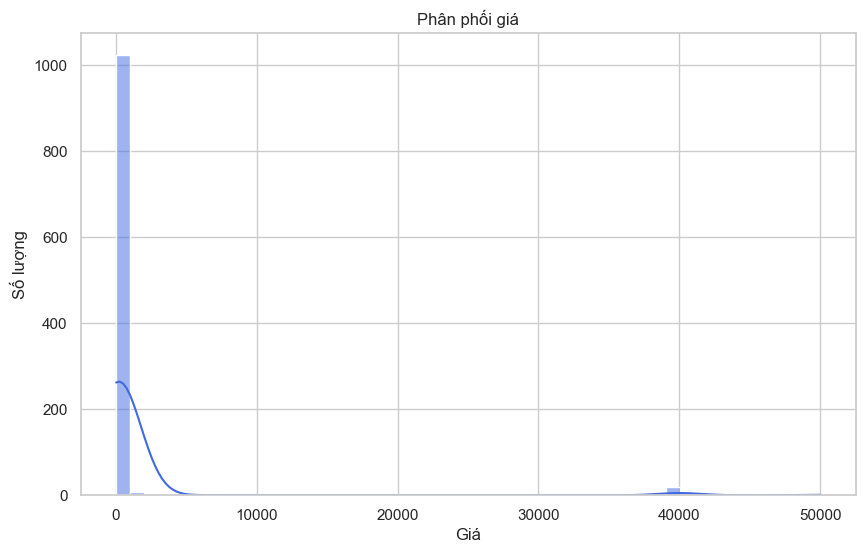

In [87]:
plt.figure(figsize=(10, 6))
sns.histplot(df_airbnbCambridge['price'], bins=50, kde=True, color='royalblue')
plt.title(f'Phân phối giá')
plt.xlabel('Giá')
plt.ylabel('Số lượng')
plt.show()

In [96]:
# 1. Tính giá ở percentile thứ 97.6
upper_limit = df_airbnbCambridge['price'].quantile(0.976)

print(f"Mốc giá tại 97.6%: ${upper_limit:.2f}")

# 2. Giữ lại 97.6% dữ liệu từ thấp đến cao
df_afterPercentile = df_airbnbCambridge[df_airbnbCambridge['price'] < upper_limit].copy()

Mốc giá tại 97.6%: $1863.26


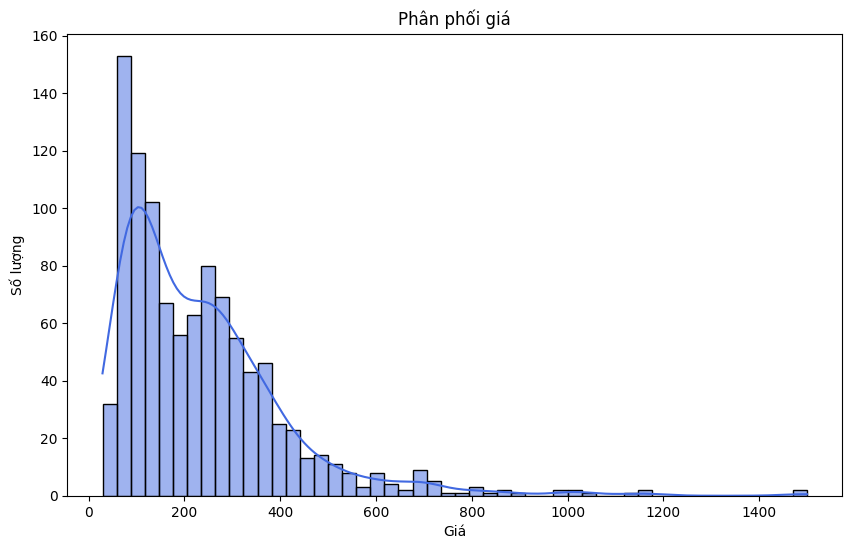

In [72]:
plt.figure(figsize=(10, 6))
sns.histplot(df_afterPercentile['price'], bins=50, kde=True, color='royalblue')
plt.title(f'Phân phối giá')
plt.xlabel('Giá')
plt.ylabel('Số lượng')
plt.show()

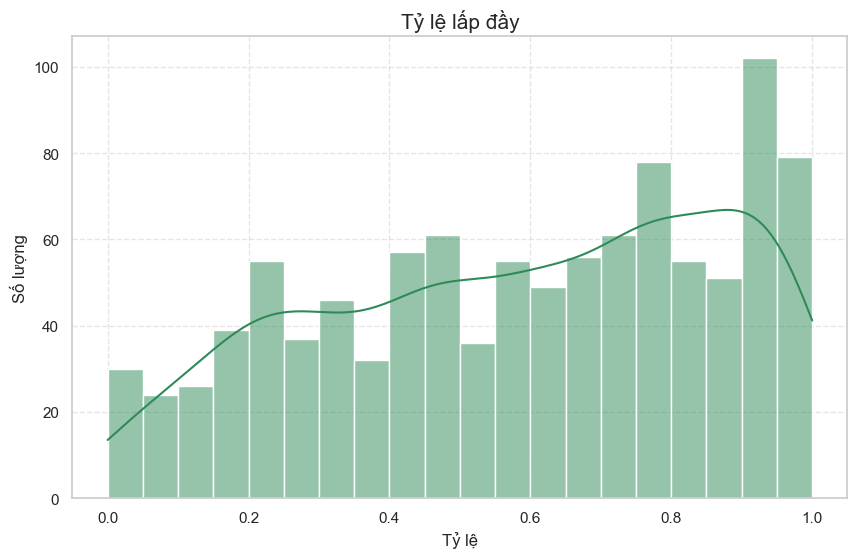

In [101]:
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Histogram cho tỷ lệ lấp đầy
sns.histplot(df_afterPercentile['occupancy_rate'], bins=20, kde=True, color='seagreen')

plt.title('Tỷ lệ lấp đầy', fontsize=15)
plt.xlabel('Tỷ lệ', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

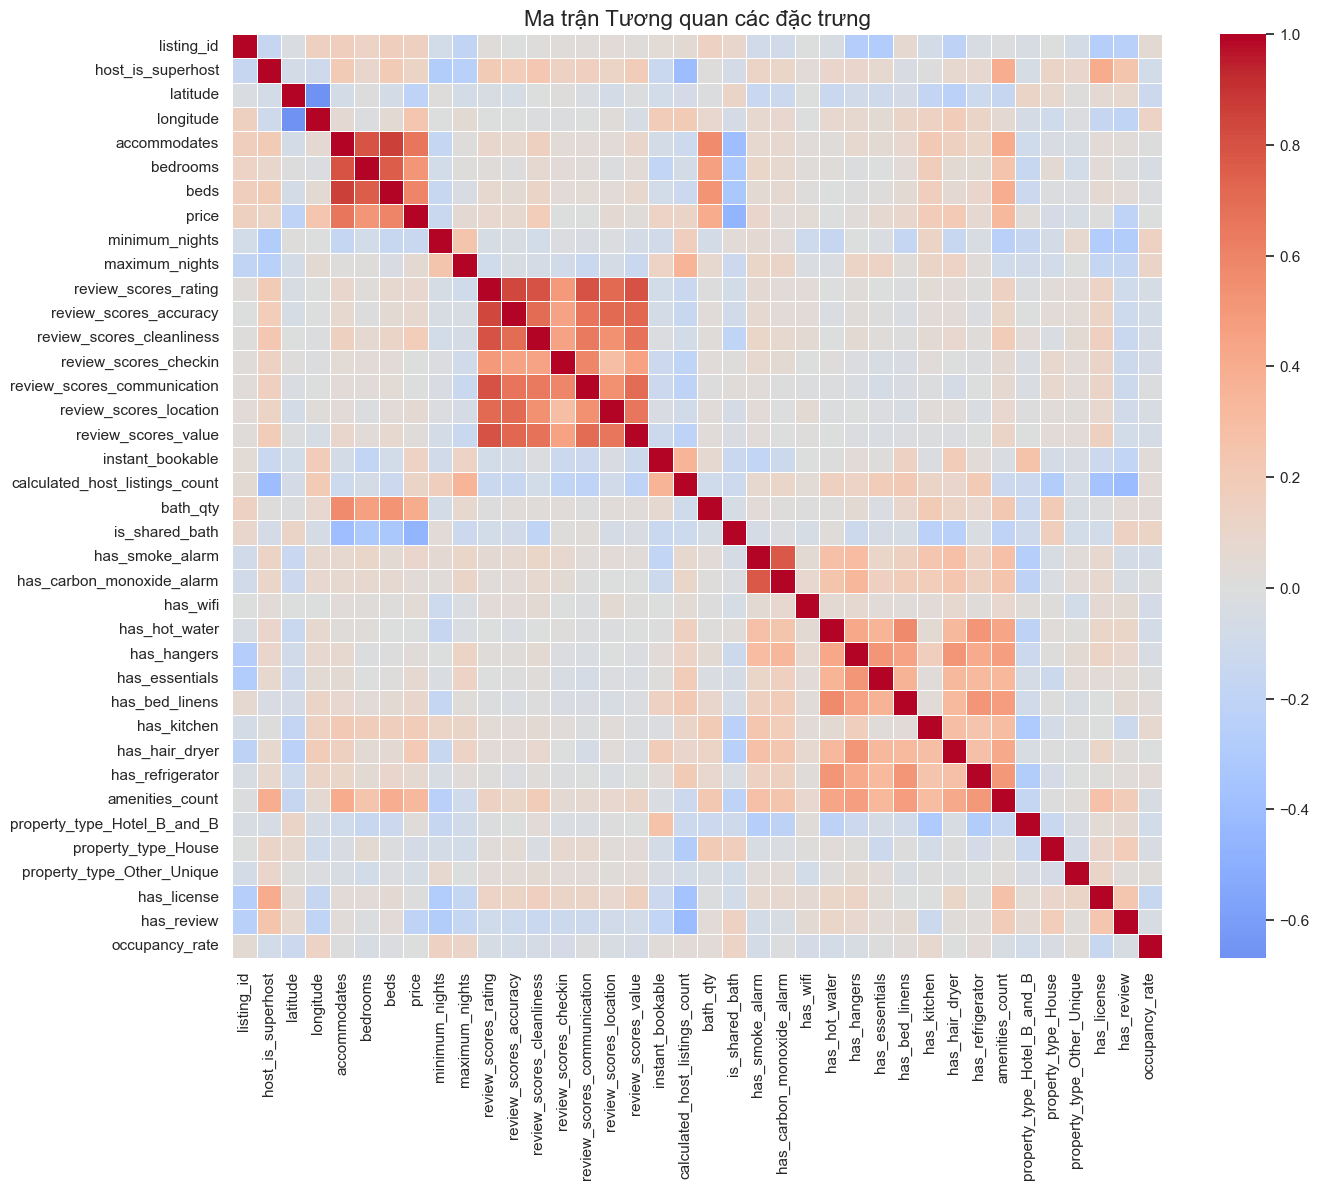

price                        1.000000
accommodates                 0.658951
beds                         0.593979
bedrooms                     0.522496
bath_qty                     0.405166
amenities_count              0.323010
longitude                    0.238689
has_hair_dryer               0.207579
has_kitchen                  0.190161
review_scores_cleanliness    0.180142
Name: price, dtype: float64


In [97]:
plt.figure(figsize=(15, 12))

# Chỉ chọn các cột dạng số để tính tương quan
numeric_df = df_afterPercentile.select_dtypes(include=['number'])

# Tính ma trận tương quan và vẽ
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, 
            annot=False, # Tắt số đi cho khỏi rối mắt vì quá nhiều cột
            linewidths=0.5)

plt.title('Ma trận Tương quan các đặc trưng', fontsize=16)
plt.show()

# Code in ra top các biến tương quan mạnh nhất với giá:
print(numeric_df.corr()['price'].sort_values(ascending=False).head(10))

In [77]:
cols_to_drop = [
    'listing_id', 
    'host_listings_count', 'host_total_listings_count',
    'beds',
    'review_scores_accuracy', 'review_scores_cleanliness', 
    'review_scores_checkin', 'review_scores_communication', 
    'review_scores_location', 'review_scores_value'
]

df_dropped = df_afterPercentile.drop(columns=cols_to_drop, errors='ignore')

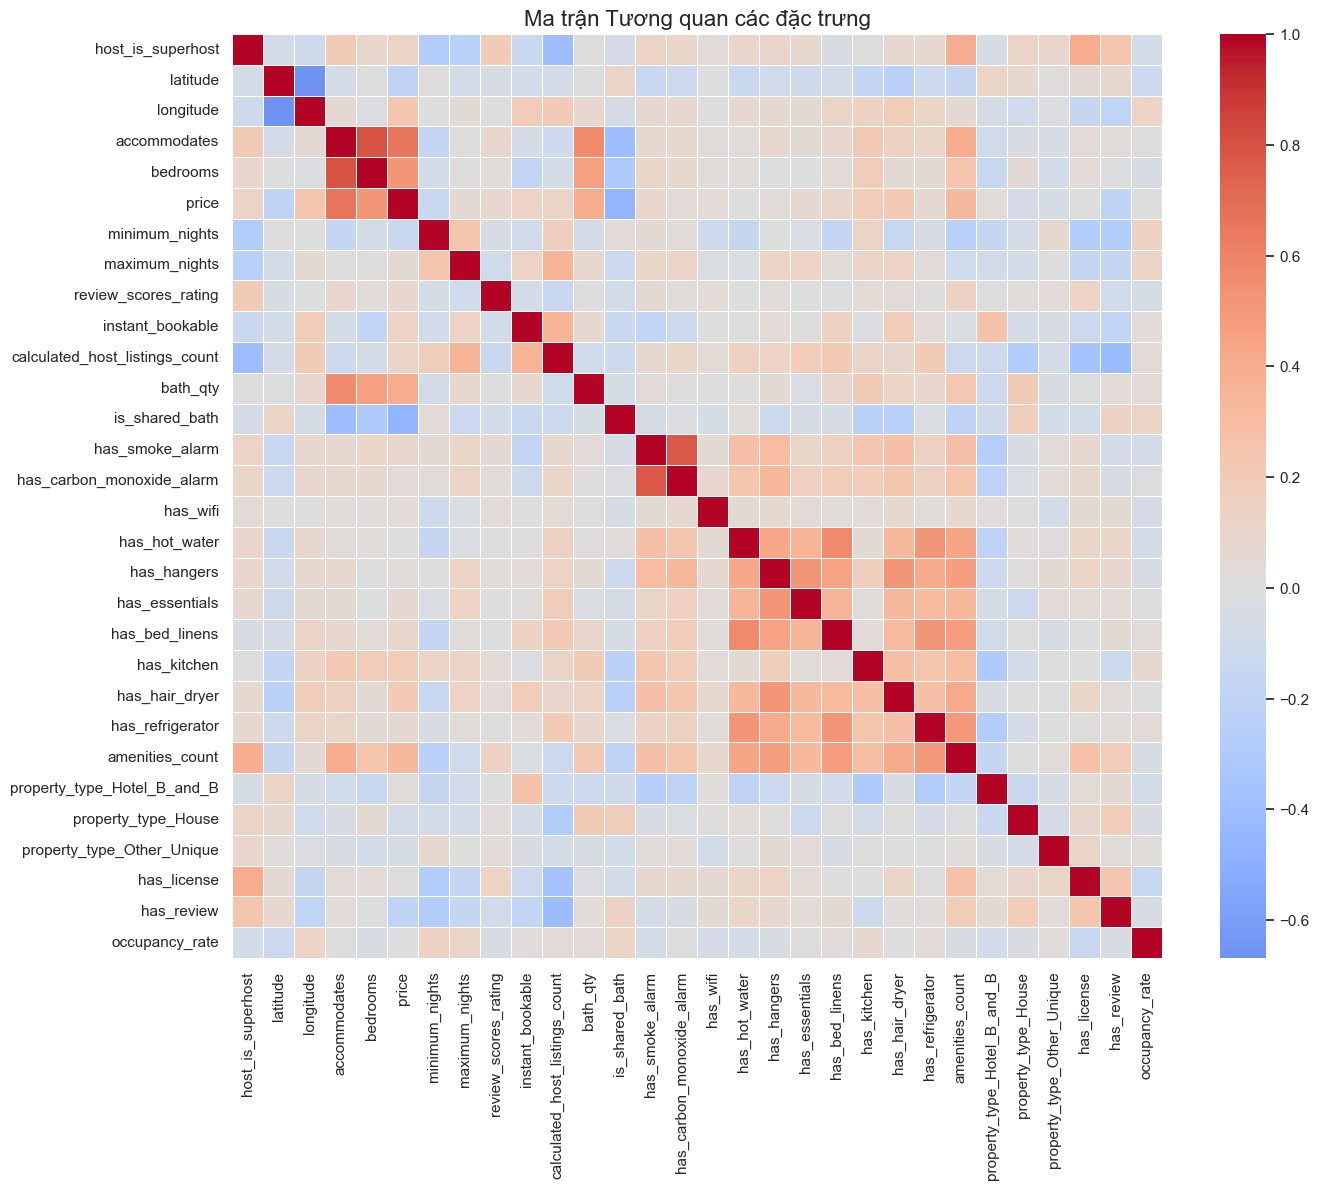

price                1.000000
accommodates         0.658951
bedrooms             0.522496
bath_qty             0.405166
amenities_count      0.323010
longitude            0.238689
has_hair_dryer       0.207579
has_kitchen          0.190161
instant_bookable     0.129688
host_is_superhost    0.123083
Name: price, dtype: float64


In [99]:
plt.figure(figsize=(15, 12))

# Chỉ chọn các cột dạng số để tính tương quan
numeric_df = df_dropped.select_dtypes(include=['number'])

# Tính ma trận tương quan và vẽ
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, 
            annot=False, # Tắt số đi cho khỏi rối mắt vì quá nhiều cột
            linewidths=0.5)

plt.title('Ma trận Tương quan các đặc trưng', fontsize=16)
plt.show()

# Code in ra top các biến tương quan mạnh nhất với giá:
print(numeric_df.corr()['price'].sort_values(ascending=False).head(10))

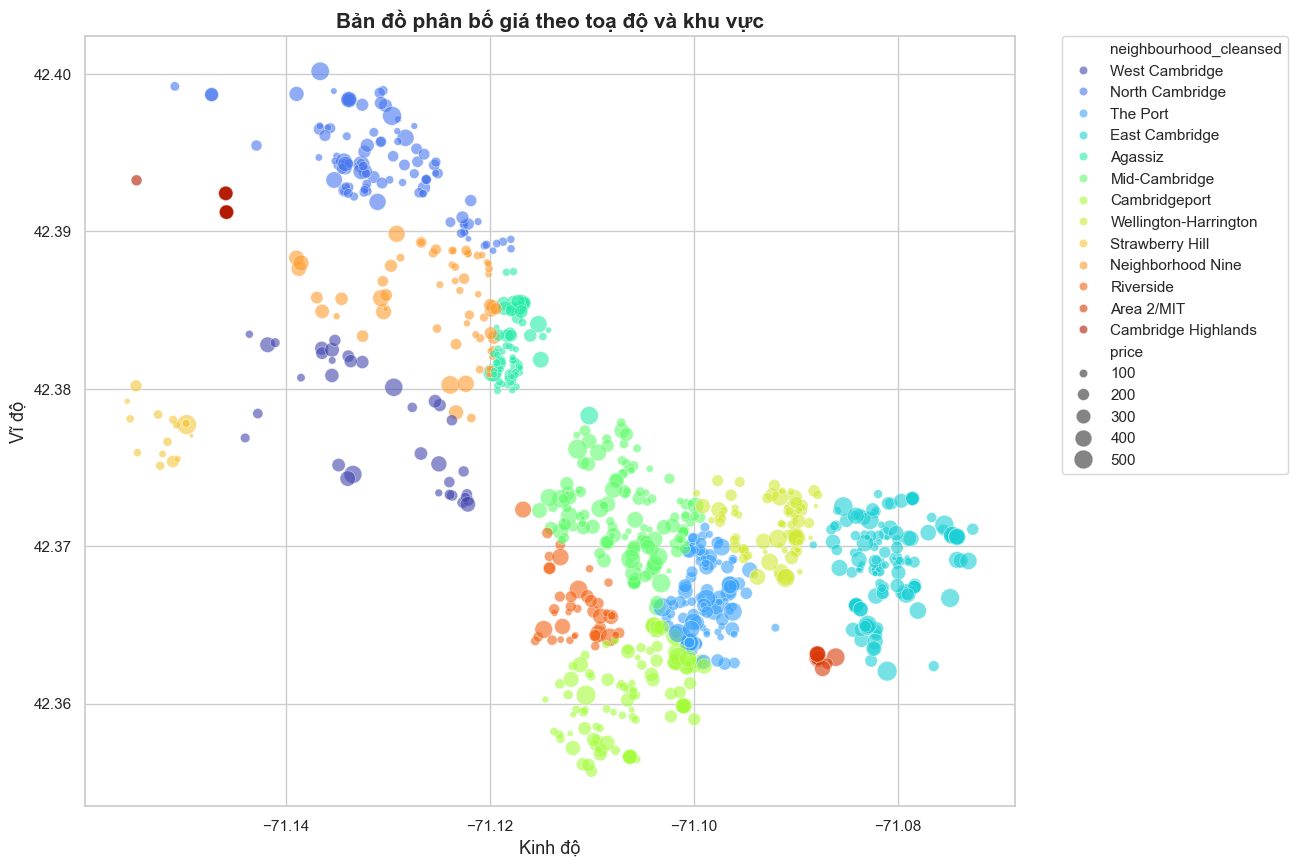

In [98]:
sns.set_theme(style="whitegrid")

# Xử lý tạm thời Outliers của Price 
price_cap_visual = df_dropped['price'].quantile(0.95)
df_visual = df_dropped[df_dropped['price'] <= price_cap_visual]

plt.figure(figsize=(12, 10))

# Vẽ scatter plot
scatter = sns.scatterplot(x='longitude', 
                          y='latitude', 
                          hue='neighbourhood_cleansed',
                          size='price',               
                          sizes=(10, 200),            
                          palette='turbo',            
                          data=df_visual, 
                          alpha=0.6)                  

max_price = df_visual['price'].max()
plt.title(f'Bản đồ phân bố giá theo toạ độ và khu vực', fontsize=15, fontweight='bold')
plt.xlabel('Kinh độ', fontsize=13)
plt.ylabel('Vĩ độ', fontsize=13)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.show()

C:\Users\CMS\AppData\Local\Temp\ipykernel_18292\2667590434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price', y='neighbourhood_cleansed', data=df_dropped, order=order, palette='viridis')


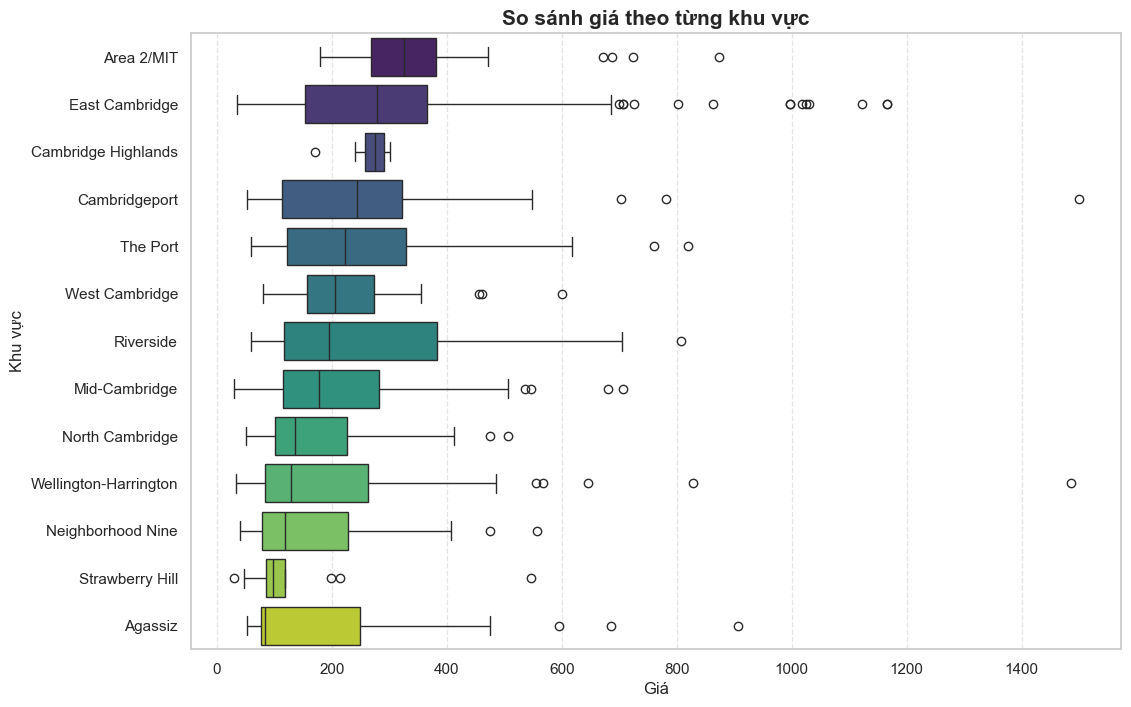

In [ ]:
plt.figure(figsize=(12, 8))
# Sắp xếp các phường theo giá trung bình từ cao xuống thấp 
order = df_dropped.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False).index

sns.boxplot(x='price', y='neighbourhood_cleansed', data=df_dropped, order=order, palette='viridis')

plt.title('So sánh giá theo từng khu vực', fontsize=15, fontweight='bold')
plt.xlabel('Giá')
plt.ylabel('Khu vực')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

C:\Users\CMS\AppData\Local\Temp\ipykernel_18292\3449528642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='room_type_Private room', y='price', data=df_dropped, palette='Pastel1')


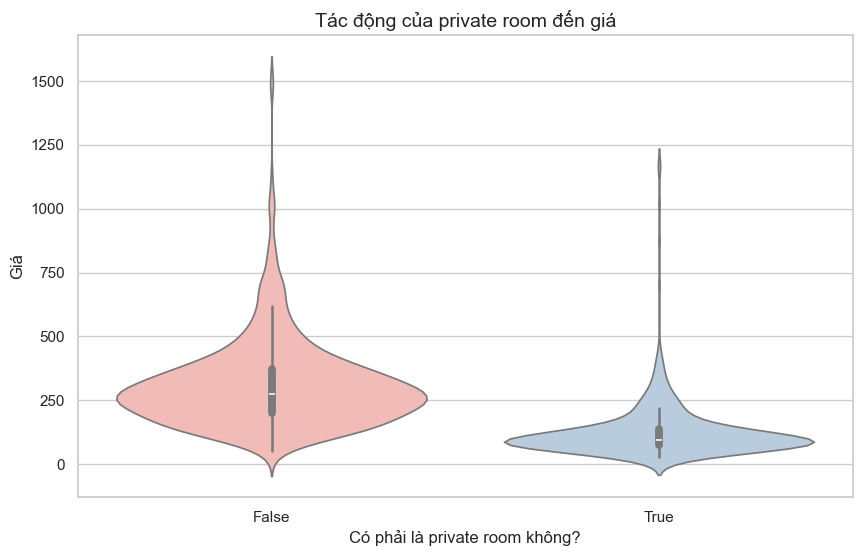

In [92]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='room_type_Private room', y='price', data=df_dropped, palette='Pastel1')
plt.title('Tác động của private room đến giá', fontsize=14)
plt.xlabel('Có phải là private room không?')
plt.ylabel('Giá')
plt.show()

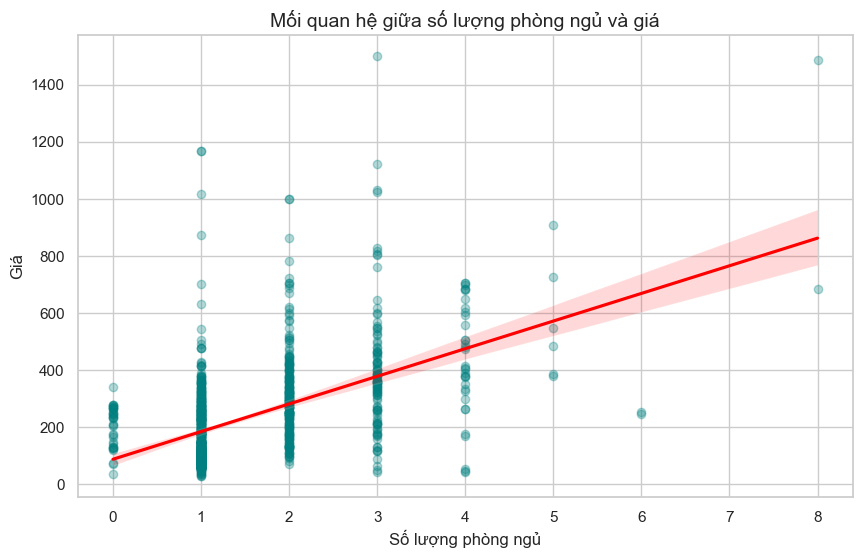

In [94]:
plt.figure(figsize=(10, 6))
# Dùng regplot để vừa vẽ scatter vừa vẽ đường hồi quy (trend line)
sns.regplot(x='bedrooms', y='price', data=df_dropped, 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Mối quan hệ giữa số lượng phòng ngủ và giá', fontsize=14)
plt.xlabel('Số lượng phòng ngủ')
plt.ylabel('Giá')
plt.show()

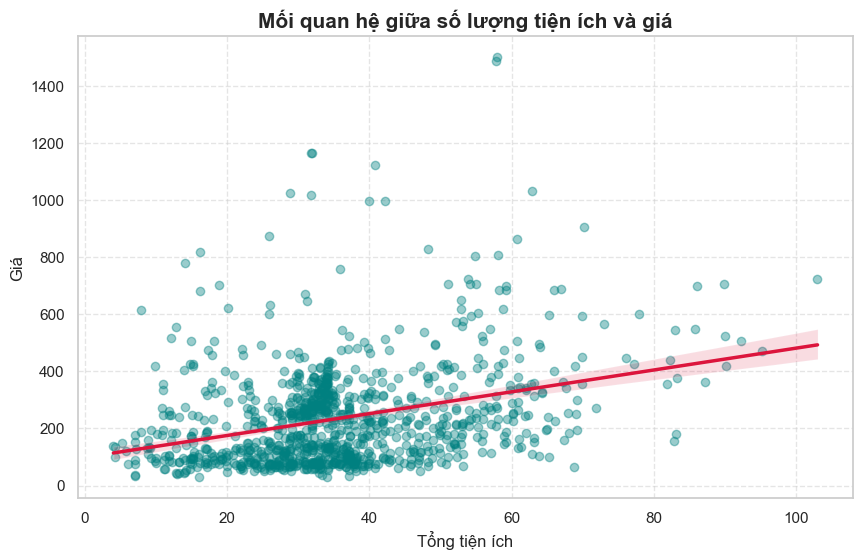

In [ ]:
plt.figure(figsize=(10, 6))

# Vẽ Scatter plot kèm đường hồi quy
# x_jitter giúp các điểm không bị dính chặt thành 1 cột dọc
sns.regplot(x='amenities_count', 
            y='price', 
            data=df_dropped, 
            scatter_kws={'alpha': 0.4, 'color': 'teal'}, 
            line_kws={'color': 'crimson', 'linewidth': 2.5},
            x_jitter=0.3)

plt.title('Mối quan hệ giữa số lượng tiện ích và giá', fontsize=15, fontweight='bold')
plt.xlabel('Tổng tiện ích', fontsize=12)
plt.ylabel('Giá', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [102]:
df_dropped.to_csv('../data/processed/df_afterEDA.csv', index=False)

In [105]:
file_path = '../data/processed/df_afterEDA.csv'
df_afterEDA = pd.read_csv(file_path)

In [ ]:
# One-Hot Encoding
# Biến các cột chữ thành các cột số 0 và 1
df_model = pd.get_dummies(df_afterEDA, drop_first=True)

# 2. Tách X (Đề bài) và y (Đáp án) từ bảng đã toàn là số
X = df_model.drop('price', axis=1)
y = df_model['price']

# 3. Khởi tạo công cụ chuẩn hóa
scaler = StandardScaler()

# 4. Chuẩn hóa (Scale) TOÀN BỘ tập X (lúc này X đã là số 100%)
X_scaled_array = scaler.fit_transform(X)

# 5. Ép ngược lại thành dạng bảng (DataFrame) để giữ lại tên các cột
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

In [109]:
# Chia tập dữ liệu (Đề bài đã Scale và Đáp án) thành 80% học, 20% thi
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [112]:
# 1. Tạo một bảng trống để lưu kết quả
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_scaled.columns

# 2. Chạy vòng lặp tính điểm VIF cho từng cột trong tập Train
vif_data["VIF"] = [
    variance_inflation_factor(X_train_scaled.values, i) 
    for i in range(len(X_train_scaled.columns))
]

# 3. Sắp xếp điểm VIF từ cao xuống thấp để tìm ra những cột có nguy cơ cao nhất
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

display(vif_data.head(10))

,Feature,VIF
0,longitude,22.547952
1,neighbourhood_cleansed_East Cambridge,19.401383
2,latitude,17.743822
3,neighbourhood_cleansed_Cambridgeport,10.224568
4,neighbourhood_cleansed_The Port,8.713054
5,neighbourhood_cleansed_Wellington-Harrington,6.691774
6,neighbourhood_cleansed_Mid-Cambridge,6.639614
7,neighbourhood_cleansed_North Cambridge,5.174144
8,accommodates,4.788925
9,neighbourhood_cleansed_Area 2/MIT,4.751260


In [113]:
# Xóa 2 cột tọa độ khỏi cả tập Train và Test
X_train_scaled = X_train_scaled.drop(['latitude', 'longitude'], axis=1)
X_test_scaled = X_test_scaled.drop(['latitude', 'longitude'], axis=1)

In [114]:
# 1. Tạo một bảng trống để lưu kết quả
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_scaled.columns

# 2. Chạy vòng lặp tính điểm VIF cho từng cột trong tập Train
vif_data["VIF"] = [
    variance_inflation_factor(X_train_scaled.values, i) 
    for i in range(len(X_train_scaled.columns))
]

# 3. Sắp xếp điểm VIF từ cao xuống thấp để tìm ra những cột có nguy cơ cao nhất
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

display(vif_data.head(10))

,Feature,VIF
0,accommodates,4.733999
1,room_type_Private room,4.343860
2,neighbourhood_cleansed_East Cambridge,3.726922
3,neighbourhood_cleansed_Mid-Cambridge,3.315127
4,bedrooms,3.279599
5,is_shared_bath,3.083613
6,neighbourhood_cleansed_The Port,2.806284
7,has_smoke_alarm,2.774718
8,amenities_count,2.756373
9,neighbourhood_cleansed_Cambridgeport,2.709328


In [115]:
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)